# Matrix Spike (MS) Data Exploration

## Overview

This notebook explores the Matrix Spike (MS) QC sample data sourced from the `SPK(MS) Assessment` sheet in `QC_Anomaly_Training_Data_v2.xlsx`. The goal is to understand the structure, distribution, and anomaly patterns in the data before building the detection model.

Matrix Spike samples assess whether the chemical matrix of a real ore sample suppresses or inflates the instrument's ability to detect a specific analyte. Each result is compared against a certified reference value (`INTERNAL_TARGET_VALUE`) and classified by CCLAS as Pass, Warning, or Failure.

### Key dataset facts
- **6,958 rows** across **57 analytes**
- **Single standard lot**: OREAS_502C
- **Two analytical schemes**: GE_ICP40Q12 and GE_IMS40Q12
- **`PARENT_NUMERIC_FINAL_VALUE` is entirely null** - recovery calculation is not possible from this export; deviation from target is used instead
- **`INSTRUMENT_ID` is entirely null** - instrument-level contextual analysis is not possible from this export


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# Load MS data
df = pd.read_excel(
    "data/raw/QC_Anomaly_Training_Data_v2.xlsx",
    sheet_name="SPK(MS) Assessment",
    engine="openpyxl"
)
df.columns = [str(c).strip().upper() for c in df.columns]
df["ANALYSED_DATE"] = pd.to_datetime(df["ANALYSED_DATE"], errors="coerce")
df["NUMERIC_FINAL_VALUE"] = pd.to_numeric(df["NUMERIC_FINAL_VALUE"], errors="coerce")
df["INTERNAL_TARGET_VALUE"] = pd.to_numeric(df["INTERNAL_TARGET_VALUE"], errors="coerce")
df["INTERNAL_MIN_VALUE"] = pd.to_numeric(df["INTERNAL_MIN_VALUE"], errors="coerce")
df["INTERNAL_MAX_VALUE"] = pd.to_numeric(df["INTERNAL_MAX_VALUE"], errors="coerce")
df["INTERNAL_MIN_WARNING_VALUE"] = pd.to_numeric(df["INTERNAL_MIN_WARNING_VALUE"], errors="coerce")
df["INTERNAL_MAX_WARNING_VALUE"] = pd.to_numeric(df["INTERNAL_MAX_WARNING_VALUE"], errors="coerce")

print(f"Rows: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"Analytes: {df['ANALYTE_CODE'].nunique()}")
print(f"Jobs: {df['JOB_CODE'].nunique()}")
print(f"Schemes: {df['SCHEME_CODE'].value_counts().to_dict()}")
print(f"Date range: {df['ANALYSED_DATE'].min()} to {df['ANALYSED_DATE'].max()}")
print(f"PARENT_NUMERIC_FINAL_VALUE non-null: {df['PARENT_NUMERIC_FINAL_VALUE'].notna().sum()}")
print(f"INSTRUMENT_ID non-null: {df['INSTRUMENT_ID'].notna().sum()}")


Rows: 6958
Columns: ['ANALYTICAL_TYPE', 'QC_TYPE', 'STD_LOT_CODE', 'STD_CODE', 'JOB_CODE', 'NUMERIC_FINAL_VALUE', 'ANALYSED_DATE', 'SCHEME_CODE', 'ANALYTE_CODE', 'STANDARD_STATUS', 'PRECISION_STATUS', 'INTERNAL_MIN_VALUE', 'INTERNAL_MAX_VALUE', 'INTERNAL_MIN_INCLUSIVE', 'INTERNAL_MAX_INCLUSIVE', 'INTERNAL_MAX_WARNING_VALUE', 'INTERNAL_MIN_WARNING_VALUE', 'INTERNAL_MIN_WARNING_INCLUSIVE', 'INTERNAL_MAX_WARNING_INCLUSIVE', 'LIM_REP_VALUE', 'STAT_DL_VALUE', 'LIM_REP_DUP_VALUE', 'STAT_DL_DUP_VALUE', 'INTERNAL_TARGET_VALUE', 'PARENT_NUMERIC_FINAL_VALUE', 'UNIT_CODE', 'SPECIFICATION_CODE', 'INSTRUMENT_ID']
Analytes: 57
Jobs: 227
Schemes: {'GE_ICP40Q12': 3660, 'GE_IMS40Q12': 3298}
Date range: 2020-06-26 04:23:55 to 2021-11-10 07:12:48
PARENT_NUMERIC_FINAL_VALUE non-null: 0
INSTRUMENT_ID non-null: 0


## 1. CCLAS Status Distribution

The first question is how CCLAS currently classifies MS results. This gives a baseline for what the detection model needs to replicate and what it needs to go beyond.

STANDARD_STATUS values in this dataset:
- **Pass** - within warning limits
- **UpperWarning / LowerWarning** - outside warning but within failure limits
- **UpperFailure / LowerFailure** - outside failure limits
- **IgnoredUpperFailure / IgnoredLowerFailure** - outside limits but manually dismissed by the chemist


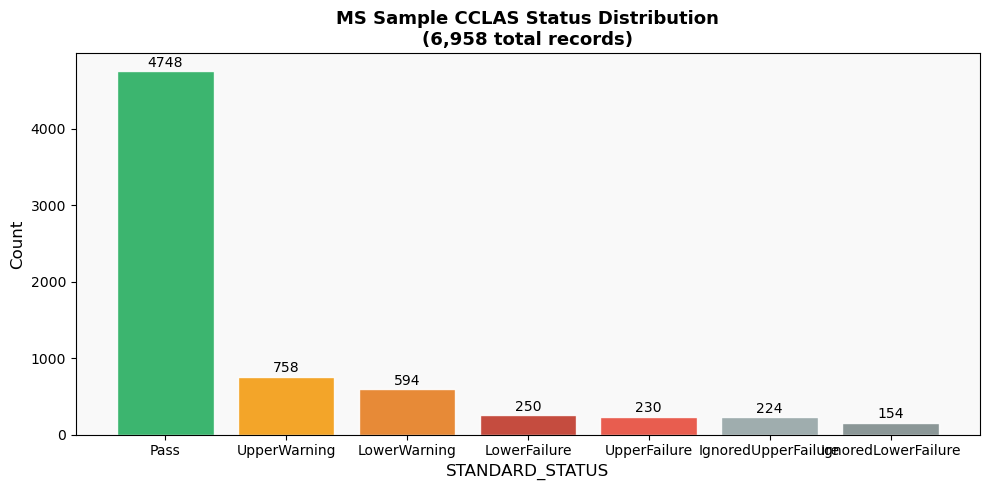


Status breakdown:
  Pass                            4748  (68.2%)
  UpperWarning                     758  (10.9%)
  LowerWarning                     594  (8.5%)
  LowerFailure                     250  (3.6%)
  UpperFailure                     230  (3.3%)
  IgnoredUpperFailure              224  (3.2%)
  IgnoredLowerFailure              154  (2.2%)


In [5]:
status_counts = df["STANDARD_STATUS"].value_counts()

colours = {
    "Pass": "#27ae60",
    "UpperWarning": "#f39c12",
    "LowerWarning": "#e67e22",
    "UpperFailure": "#e74c3c",
    "LowerFailure": "#c0392b",
    "IgnoredUpperFailure": "#95a5a6",
    "IgnoredLowerFailure": "#7f8c8d",
}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    status_counts.index,
    status_counts.values,
    color=[colours.get(s, "#3498db") for s in status_counts.index],
    alpha=0.9,
    edgecolor="white"
)
for bar, val in zip(bars, status_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(val), ha="center", va="bottom", fontsize=10)

ax.set_xlabel("STANDARD_STATUS", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("MS Sample CCLAS Status Distribution\n(6,958 total records)", fontsize=13, fontweight="bold")
ax.set_facecolor("#f9f9f9")
fig.tight_layout()
plt.show()

print("\nStatus breakdown:")
for status, count in status_counts.items():
    pct = count / len(df) * 100
    print(f"  {status:<30} {count:>5}  ({pct:.1f}%)")


**Interpretation:**

The majority of MS results (68.2%) are classified as Pass. However, 18.1% are in Warning territory (UpperWarning or LowerWarning) and 6.9% are outright failures. A further 5.4% are ignored failures. These are results that CCLAS flagged as failures but the chemist manually dismissed.

This is important for the detection model: the 5.4% of ignored failures are non-representative data and should be excluded from training baselines, consistent with Datamine's guidance. The 18.1% warning results are the most interesting target. These are the boundary cases that rule-based checking struggles with and where machine learning adds the most value.


## 2. Target Deviation Distribution

Since `PARENT_NUMERIC_FINAL_VALUE` is entirely null, recovery percentage cannot be computed. Instead, deviation from `INTERNAL_TARGET_VALUE` is used as the primary feature:

**TARGET_DEVIATION = NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE**

A positive deviation means the result is above target (potential inflation). A negative deviation means the result is below target (potential suppression).


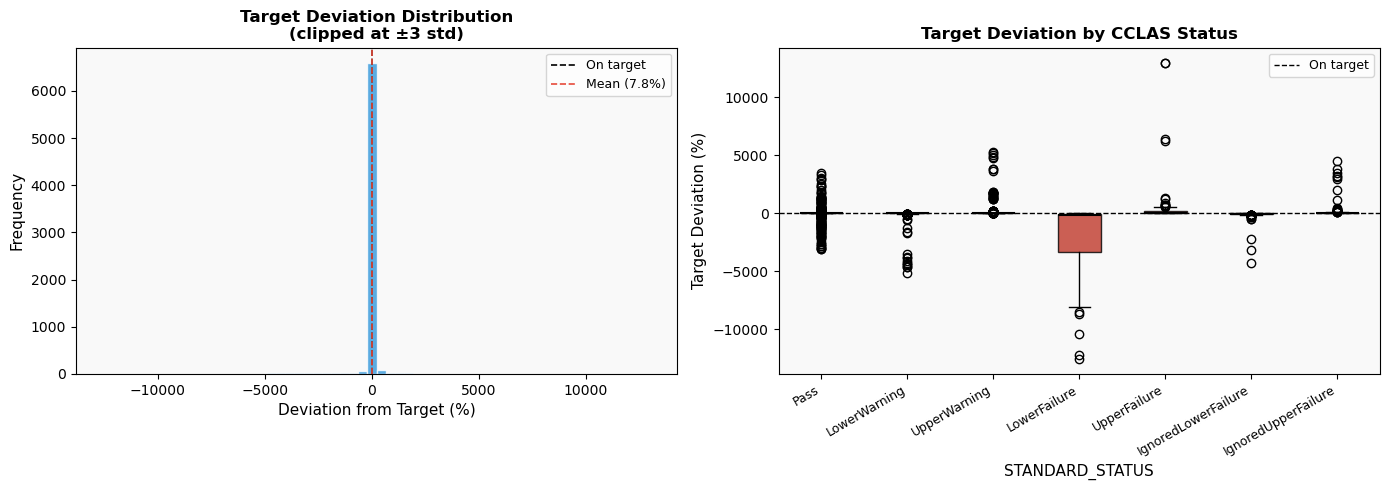

TARGET_DEVIATION_PCT summary:
count      6958.00
mean          7.82
std        4326.29
min      -12561.35
25%          -6.22
50%           1.16
75%           8.34
max      352117.80
Name: TARGET_DEVIATION_PCT, dtype: float64


In [6]:
df["TARGET_DEVIATION"] = df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_TARGET_VALUE"]
df["TARGET_DEVIATION_PCT"] = (df["TARGET_DEVIATION"] / df["INTERNAL_TARGET_VALUE"]) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: deviation distribution clipped to ±3 std for readability
std = df["TARGET_DEVIATION_PCT"].std()
mean = df["TARGET_DEVIATION_PCT"].mean()
clip_low, clip_high = mean - 3*std, mean + 3*std
clipped = df["TARGET_DEVIATION_PCT"].clip(clip_low, clip_high)

axes[0].hist(clipped, bins=60, color="#3498db", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2, label="On target")
axes[0].axvline(mean, color="#e74c3c", linestyle="--", linewidth=1.2, label=f"Mean ({mean:.1f}%)")
axes[0].set_xlabel("Deviation from Target (%)", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Target Deviation Distribution\n(clipped at ±3 std)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].set_facecolor("#f9f9f9")

# Right: deviation by status
status_order = ["Pass", "LowerWarning", "UpperWarning", "LowerFailure", "UpperFailure",
                "IgnoredLowerFailure", "IgnoredUpperFailure"]
status_colours = ["#27ae60", "#e67e22", "#f39c12", "#c0392b", "#e74c3c", "#7f8c8d", "#95a5a6"]

data_by_status = [
    df[df["STANDARD_STATUS"] == s]["TARGET_DEVIATION_PCT"].dropna().clip(clip_low, clip_high)
    for s in status_order
]
bp = axes[1].boxplot(data_by_status, labels=status_order, patch_artist=True,
                     medianprops=dict(color="black", linewidth=1.5))
for patch, colour in zip(bp["boxes"], status_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1, label="On target")
axes[1].set_xlabel("STANDARD_STATUS", fontsize=11)
axes[1].set_ylabel("Target Deviation (%)", fontsize=11)
axes[1].set_title("Target Deviation by CCLAS Status", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(status_order, rotation=30, ha="right", fontsize=9)
axes[1].set_facecolor("#f9f9f9")
axes[1].legend(fontsize=9)

fig.tight_layout()
plt.show()

print("TARGET_DEVIATION_PCT summary:")
print(df["TARGET_DEVIATION_PCT"].describe().round(2))


**Interpretation:**

The deviation distribution is approximately centred near zero. However there is a visible spread, with some results showing large positive or negative deviations indicating matrix interference.

The boxplot by status confirms the pattern: Pass results cluster tightly around zero, while Warning and Failure results show larger and more variable deviations in both directions. Ignored failures overlap substantially with active failures, confirming they should be excluded from modelling baselines.


## 3. Status Distribution by Analyte

Not all analytes behave the same way. Some are more prone to matrix interference than others due to their chemical properties. This plot shows the failure and warning rate per analyte.


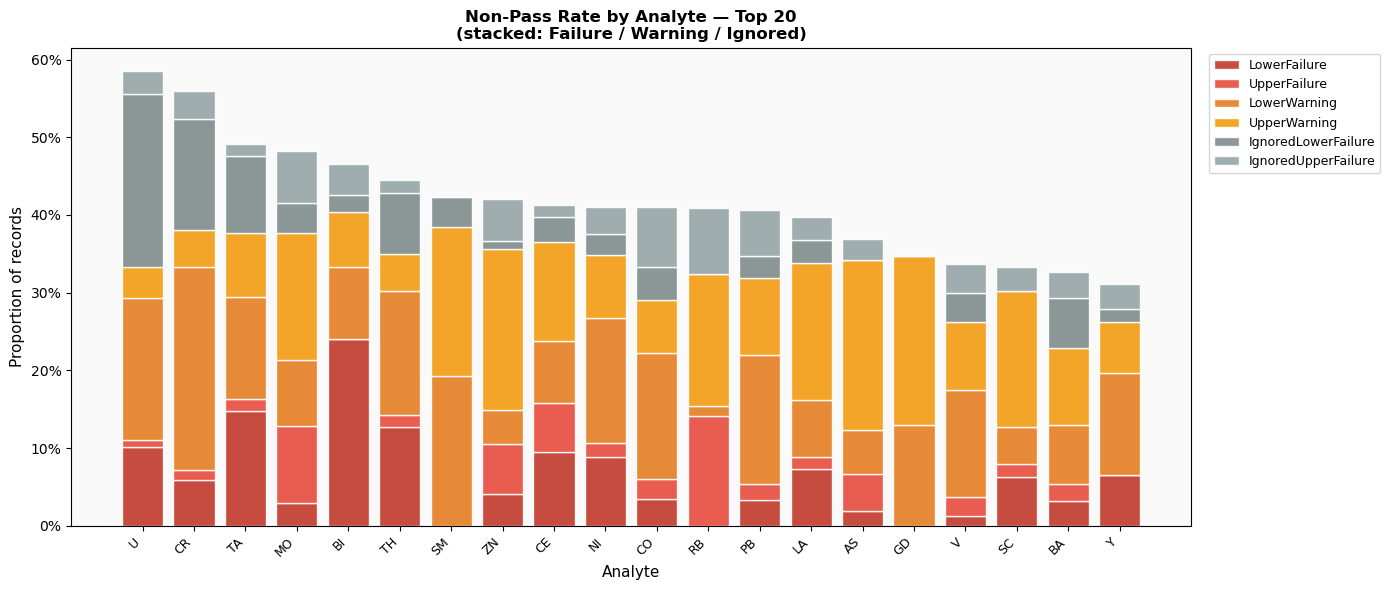

Top 10 analytes by non-pass rate:
ANALYTE_CODE
U     0.586
CR    0.560
TA    0.492
MO    0.482
BI    0.465
TH    0.444
SM    0.423
ZN    0.421
CE    0.413
NI    0.411


In [7]:
# Failure + warning rate per analyte
analyte_stats = df.groupby("ANALYTE_CODE")["STANDARD_STATUS"].value_counts(normalize=True).unstack(fill_value=0)

# Add any missing status columns
for col in ["Pass", "UpperWarning", "LowerWarning", "UpperFailure", "LowerFailure",
            "IgnoredUpperFailure", "IgnoredLowerFailure"]:
    if col not in analyte_stats.columns:
        analyte_stats[col] = 0

analyte_stats["non_pass_rate"] = 1 - analyte_stats.get("Pass", 0)
analyte_stats = analyte_stats.sort_values("non_pass_rate", ascending=False)

top_analytes = analyte_stats.head(20)

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(top_analytes))
plot_cols = [
    ("LowerFailure", "#c0392b"),
    ("UpperFailure", "#e74c3c"),
    ("LowerWarning", "#e67e22"),
    ("UpperWarning", "#f39c12"),
    ("IgnoredLowerFailure", "#7f8c8d"),
    ("IgnoredUpperFailure", "#95a5a6"),
]

for col, colour in plot_cols:
    if col in top_analytes.columns:
        vals = top_analytes[col].values
        ax.bar(top_analytes.index, vals, bottom=bottom,
               color=colour, alpha=0.9, label=col, edgecolor="white")
        bottom += vals

ax.set_xlabel("Analyte", fontsize=11)
ax.set_ylabel("Proportion of records", fontsize=11)
ax.set_title("Non-Pass Rate by Analyte — Top 20\n(stacked: Failure / Warning / Ignored)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(top_analytes.index, rotation=45, ha="right", fontsize=9)
ax.set_facecolor("#f9f9f9")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
fig.tight_layout()
plt.show()

print("Top 10 analytes by non-pass rate:")
print(analyte_stats["non_pass_rate"].head(10).round(3).to_string())


**Interpretation:**

Analyte-specific failure rates vary significantly. Some analytes show much higher proportions of Warning and Failure results than others, reflecting differences in how susceptible each element is to matrix interference in ore samples. This confirms that a single global threshold is not appropriate, detection thresholds must be evaluated within each analyte context, which is enforced by the per-analyte grouping in the detection model.


## 4. Normalised Deviation Score

Since analytes operate at very different concentration scales, for example Zinc at ~390 mg/kg versus Indium at ~0.089 mg/kg, raw deviations cannot be compared directly across analytes. A normalised deviation score places each result on a common 0-to-±1 scale relative to its warning boundary:

**norm_dev = (NUMERIC_FINAL_VALUE - INTERNAL_TARGET_VALUE) / (warning_bound - INTERNAL_TARGET_VALUE)**

Where `warning_bound` is the upper warning value if the result is above target, and the lower warning value if below. A score of 0 = on target, ±1 = at the warning boundary, beyond ±1 = outside warning limits.


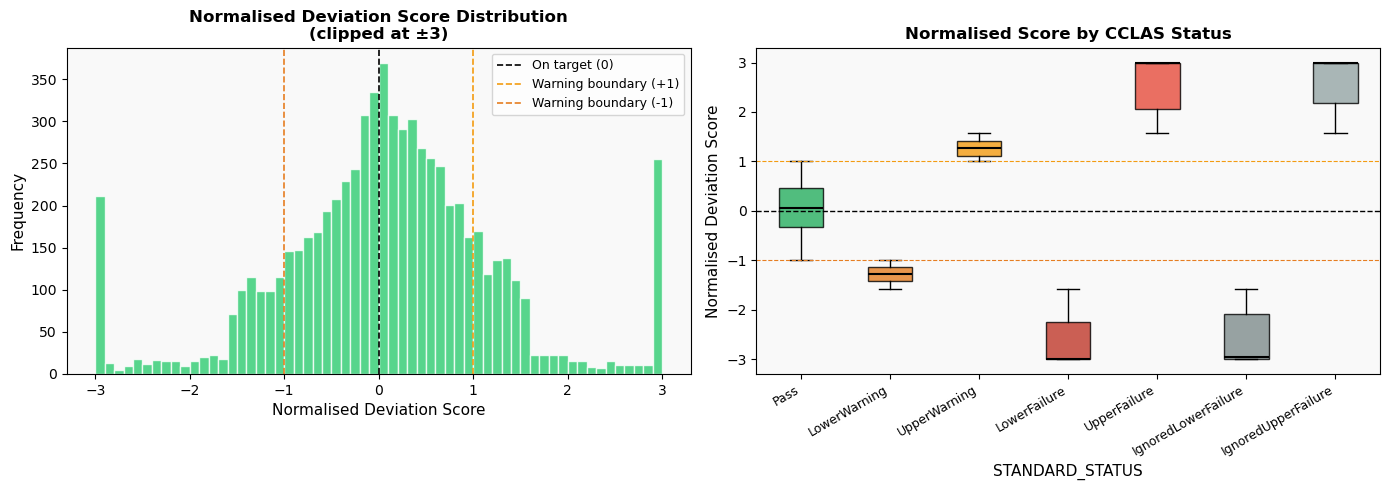

Normalised deviation score summary:
count    6958.000
mean        0.823
std        41.415
min       -23.249
25%        -0.536
50%         0.093
75%         0.718
max      3256.731
Name: NORM_DEV, dtype: float64

Records with |norm_dev| > 1 (outside warning): 2210
Records with |norm_dev| > 0 and <= 1 (within warning zone): 4745


In [8]:
df["NORM_DEV"] = np.where(
    df["NUMERIC_FINAL_VALUE"] >= df["INTERNAL_TARGET_VALUE"],
    np.where(
        (df["INTERNAL_MAX_WARNING_VALUE"] - df["INTERNAL_TARGET_VALUE"]) != 0,
        (df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_TARGET_VALUE"]) /
        (df["INTERNAL_MAX_WARNING_VALUE"] - df["INTERNAL_TARGET_VALUE"]),
        np.nan
    ),
    np.where(
        (df["INTERNAL_TARGET_VALUE"] - df["INTERNAL_MIN_WARNING_VALUE"]) != 0,
        (df["NUMERIC_FINAL_VALUE"] - df["INTERNAL_TARGET_VALUE"]) /
        (df["INTERNAL_TARGET_VALUE"] - df["INTERNAL_MIN_WARNING_VALUE"]),
        np.nan
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of normalised score
clipped_norm = df["NORM_DEV"].clip(-3, 3)
axes[0].hist(clipped_norm, bins=60, color="#2ecc71", alpha=0.8, edgecolor="white")
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2, label="On target (0)")
axes[0].axvline(1, color="#f39c12", linestyle="--", linewidth=1.2, label="Warning boundary (+1)")
axes[0].axvline(-1, color="#e67e22", linestyle="--", linewidth=1.2, label="Warning boundary (-1)")
axes[0].set_xlabel("Normalised Deviation Score", fontsize=11)
axes[0].set_ylabel("Frequency", fontsize=11)
axes[0].set_title("Normalised Deviation Score Distribution\n(clipped at ±3)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].set_facecolor("#f9f9f9")

# Score by status
data_norm_by_status = [
    df[df["STANDARD_STATUS"] == s]["NORM_DEV"].dropna().clip(-3, 3)
    for s in status_order
]
bp2 = axes[1].boxplot(data_norm_by_status, labels=status_order, patch_artist=True,
                      medianprops=dict(color="black", linewidth=1.5))
for patch, colour in zip(bp2["boxes"], status_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)

axes[1].axhline(0, color="black", linestyle="--", linewidth=1, label="On target")
axes[1].axhline(1, color="#f39c12", linestyle="--", linewidth=0.8)
axes[1].axhline(-1, color="#e67e22", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("STANDARD_STATUS", fontsize=11)
axes[1].set_ylabel("Normalised Deviation Score", fontsize=11)
axes[1].set_title("Normalised Score by CCLAS Status", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(status_order, rotation=30, ha="right", fontsize=9)
axes[1].set_facecolor("#f9f9f9")

fig.tight_layout()
plt.show()

print("Normalised deviation score summary:")
print(df["NORM_DEV"].describe().round(3))
print(f"\nRecords with |norm_dev| > 1 (outside warning): {(df['NORM_DEV'].abs() > 1).sum()}")
print(f"Records with |norm_dev| > 0 and <= 1 (within warning zone): {((df['NORM_DEV'].abs() > 0) & (df['NORM_DEV'].abs() <= 1)).sum()}")


**Interpretation:**

The normalised score distribution confirms that most results cluster near zero (on target). The boxplot shows a clean separation between Pass results (scores near 0) and Failure results (scores beyond ±1). Warning results sit in the expected intermediate zone. This validates the normalised deviation score as the primary feature for detection, it captures the same information as raw deviation but on a scale that works consistently across all 57 analytes.


## 5. Temporal Analysis - Results Over Time

Examining how MS results behave over time helps identify whether there are periods of sustained deviation, drift patterns that a rolling mean approach can detect.


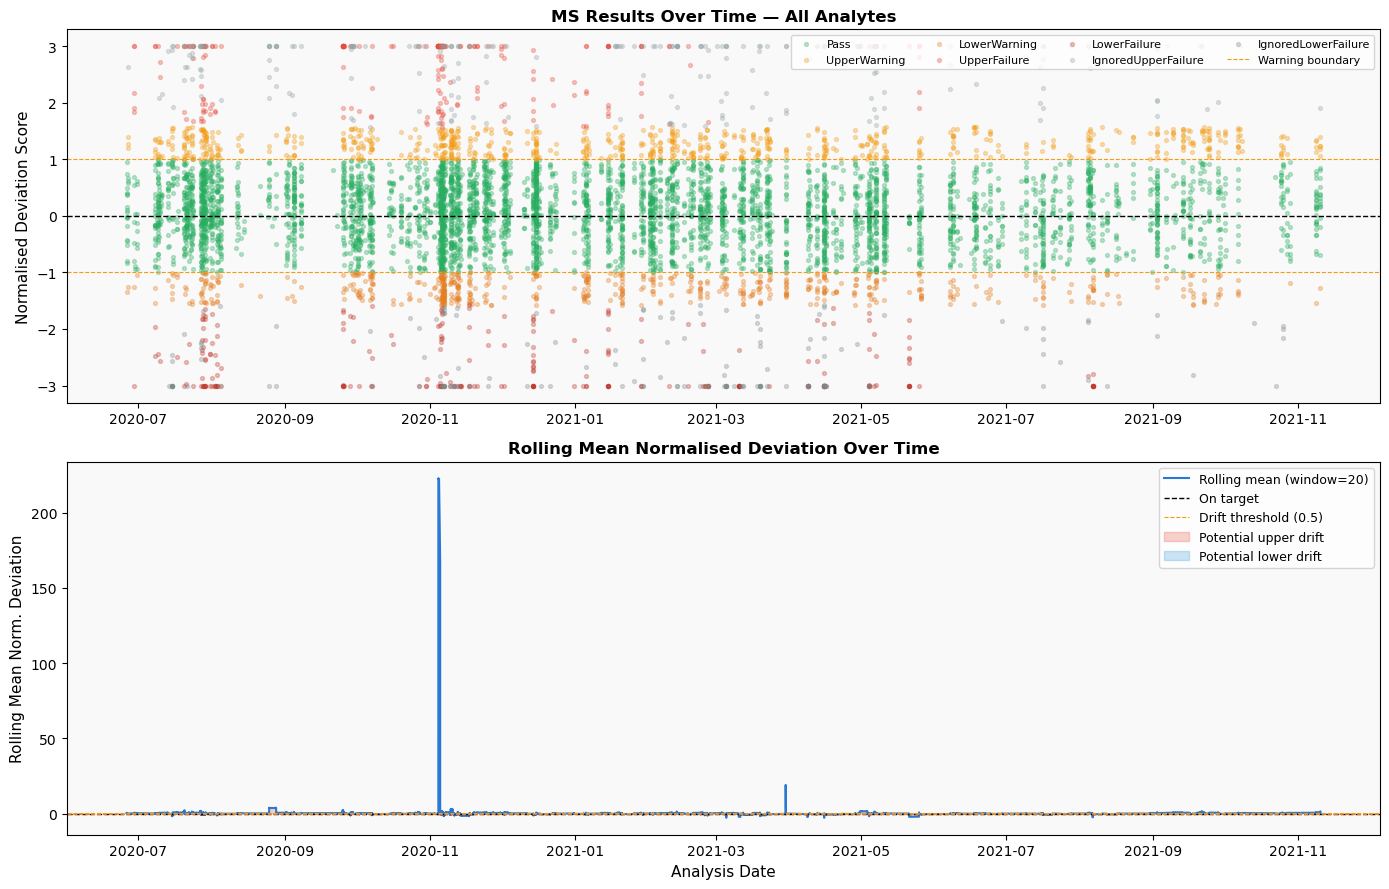

In [9]:
df_sorted = df.dropna(subset=["ANALYSED_DATE", "NORM_DEV"]).sort_values("ANALYSED_DATE")

# Rolling mean of normalised deviation across all analytes over time
df_sorted["ROLLING_NORM_DEV"] = df_sorted["NORM_DEV"].rolling(window=20, min_periods=5).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Top: scatter of all results coloured by status
status_colour_map = {
    "Pass": "#27ae60",
    "UpperWarning": "#f39c12",
    "LowerWarning": "#e67e22",
    "UpperFailure": "#e74c3c",
    "LowerFailure": "#c0392b",
    "IgnoredUpperFailure": "#95a5a6",
    "IgnoredLowerFailure": "#7f8c8d",
}

for status, colour in status_colour_map.items():
    subset = df_sorted[df_sorted["STANDARD_STATUS"] == status]
    axes[0].scatter(subset["ANALYSED_DATE"], subset["NORM_DEV"].clip(-3, 3),
                    c=colour, alpha=0.3, s=8, label=status)

axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(1, color="#f39c12", linestyle="--", linewidth=0.8, label="Warning boundary")
axes[0].axhline(-1, color="#f39c12", linestyle="--", linewidth=0.8)
axes[0].set_ylabel("Normalised Deviation Score", fontsize=11)
axes[0].set_title("MS Results Over Time — All Analytes", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=8, ncol=4, loc="upper right")
axes[0].set_facecolor("#f9f9f9")

# Bottom: rolling mean
axes[1].plot(df_sorted["ANALYSED_DATE"], df_sorted["ROLLING_NORM_DEV"],
             color="#2a78d6", linewidth=1.5, label="Rolling mean (window=20)")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1, label="On target")
axes[1].axhline(0.5, color="#f39c12", linestyle="--", linewidth=0.8, label="Drift threshold (0.5)")
axes[1].axhline(-0.5, color="#e67e22", linestyle="--", linewidth=0.8)
axes[1].fill_between(df_sorted["ANALYSED_DATE"],
                     df_sorted["ROLLING_NORM_DEV"], 0,
                     where=df_sorted["ROLLING_NORM_DEV"] > 0.5,
                     alpha=0.25, color="#e74c3c", label="Potential upper drift")
axes[1].fill_between(df_sorted["ANALYSED_DATE"],
                     df_sorted["ROLLING_NORM_DEV"], 0,
                     where=df_sorted["ROLLING_NORM_DEV"] < -0.5,
                     alpha=0.25, color="#3498db", label="Potential lower drift")
axes[1].set_xlabel("Analysis Date", fontsize=11)
axes[1].set_ylabel("Rolling Mean Norm. Deviation", fontsize=11)
axes[1].set_title("Rolling Mean Normalised Deviation Over Time", fontsize=12, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].set_facecolor("#f9f9f9")

fig.tight_layout()
plt.show()


**Interpretation:**

The temporal scatter shows that Warning and Failure results are not evenly distributed over time. There appear to be periods of elevated anomaly density. The rolling mean plot makes this clearer, showing when the average normalised deviation sustains a meaningful drift away from zero. Periods where the rolling mean exceeds the drift threshold (±0.5 in this view) are candidate drift events worth investigating. These are patterns that CCLAS's individual result checking cannot detect.


## 6. Per-Analyte Deep Dive — Top Failing Analytes

This section examines the five analytes with the highest non-pass rates in more detail, showing their measured values against their target, warning, and failure bounds.


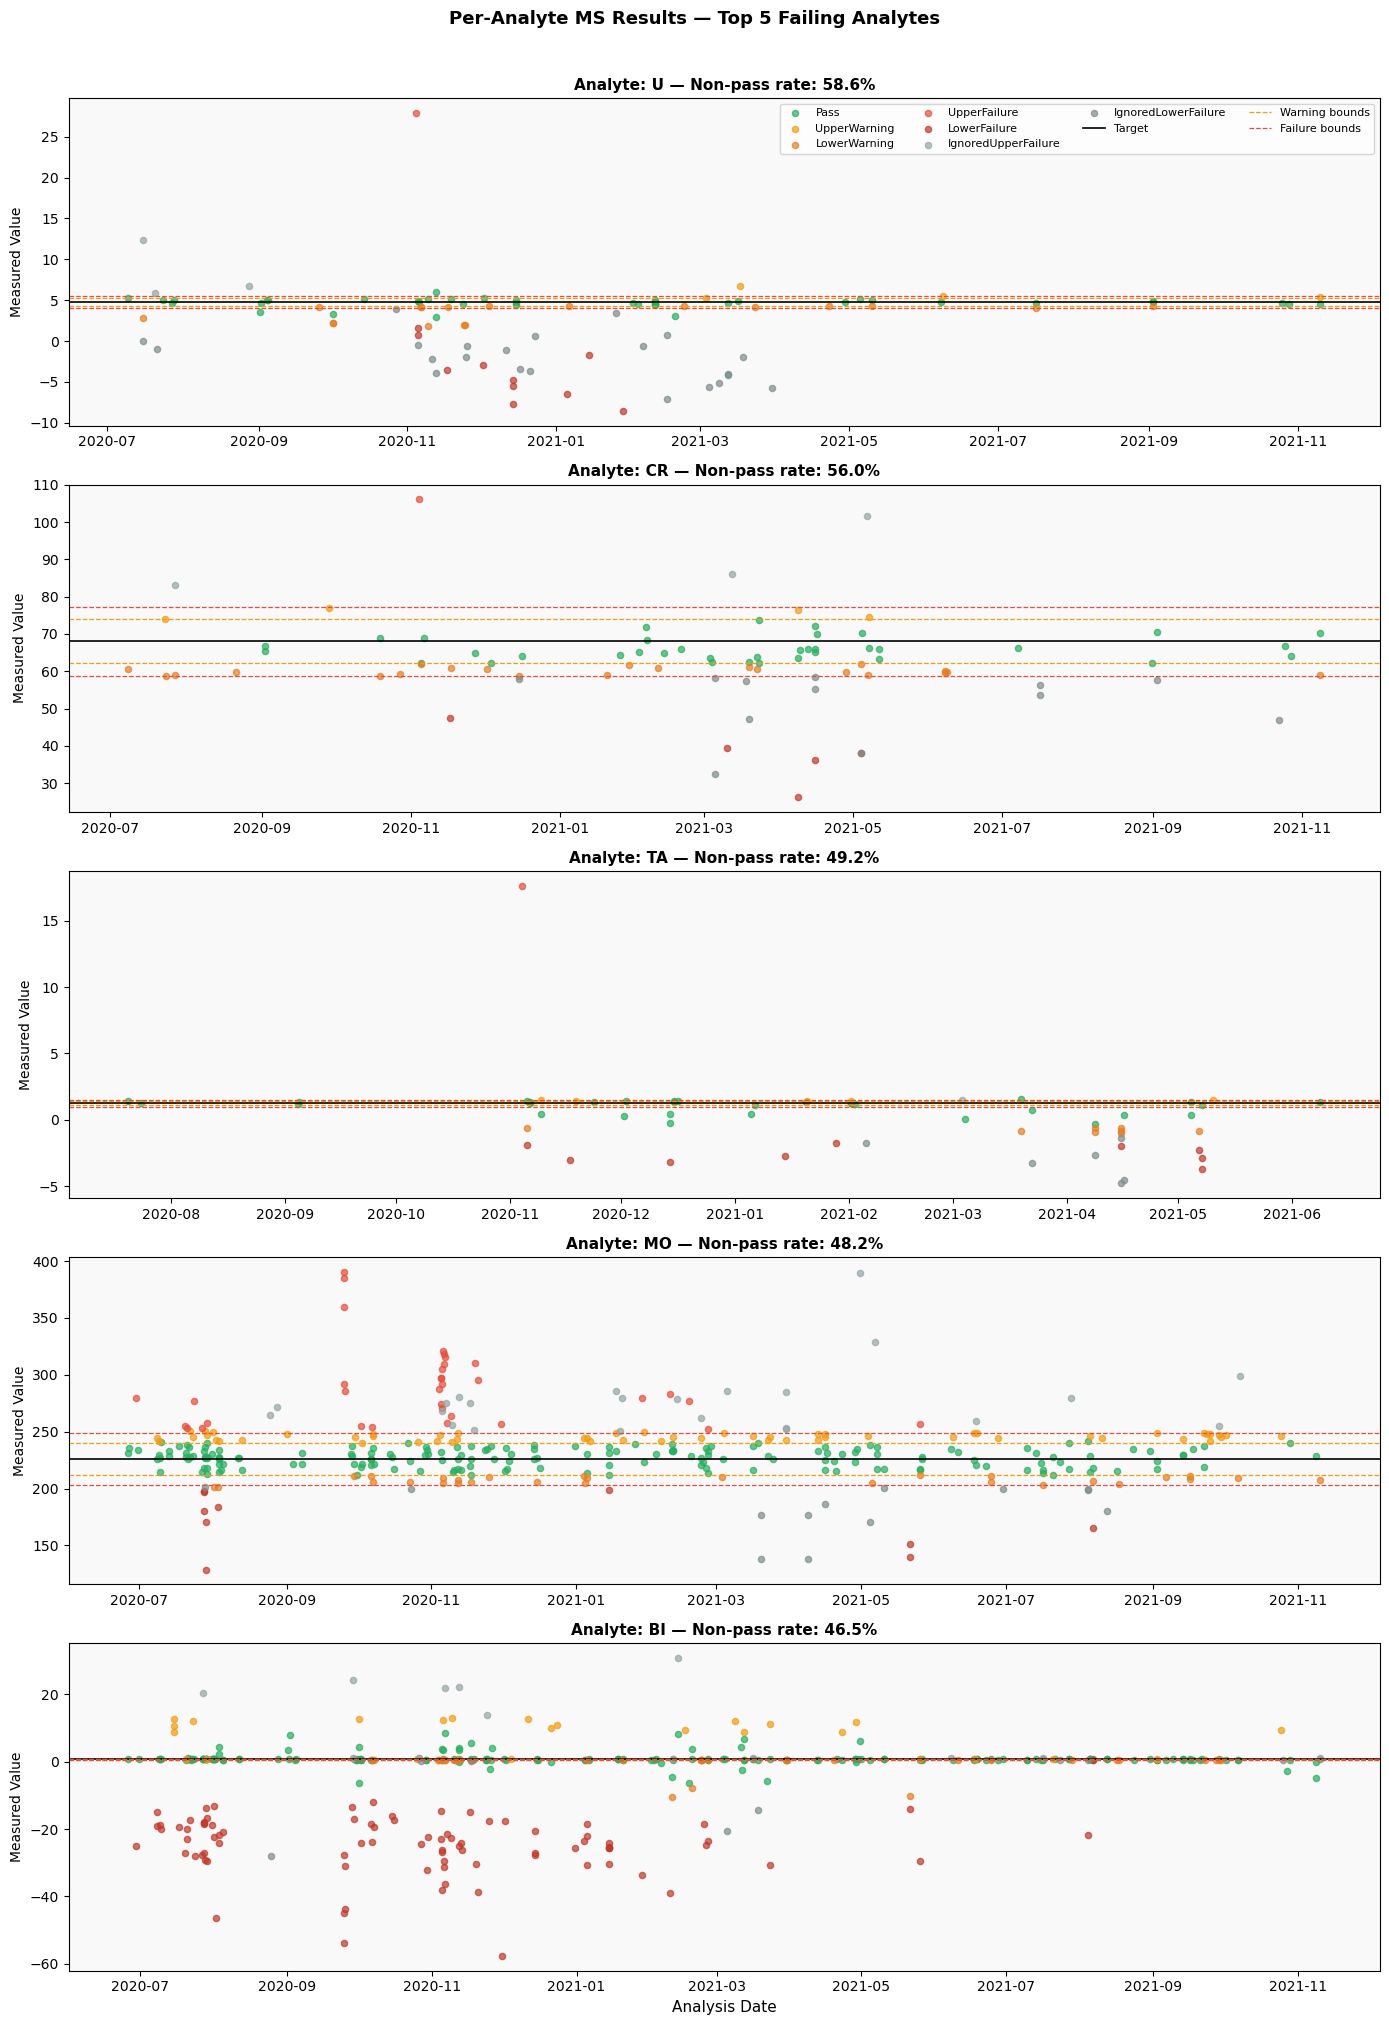

In [10]:
top_failing = analyte_stats["non_pass_rate"].head(5).index.tolist()

fig, axes = plt.subplots(len(top_failing), 1, figsize=(14, 4 * len(top_failing)))

for i, analyte in enumerate(top_failing):
    ax = axes[i]
    adf = df[df["ANALYTE_CODE"] == analyte].sort_values("ANALYSED_DATE").dropna(subset=["ANALYSED_DATE"])

    for status, colour in status_colour_map.items():
        subset = adf[adf["STANDARD_STATUS"] == status]
        ax.scatter(subset["ANALYSED_DATE"], subset["NUMERIC_FINAL_VALUE"],
                   c=colour, alpha=0.7, s=20, label=status if i == 0 else "")

    # Draw reference lines using first row values (same for all rows per analyte)
    if len(adf) > 0:
        row = adf.iloc[0]
        ax.axhline(row["INTERNAL_TARGET_VALUE"], color="black", linestyle="-",
                   linewidth=1.2, label="Target" if i == 0 else "")
        ax.axhline(row["INTERNAL_MAX_WARNING_VALUE"], color="#f39c12", linestyle="--",
                   linewidth=0.9, label="Warning bounds" if i == 0 else "")
        ax.axhline(row["INTERNAL_MIN_WARNING_VALUE"], color="#f39c12", linestyle="--", linewidth=0.9)
        ax.axhline(row["INTERNAL_MAX_VALUE"], color="#e74c3c", linestyle="--",
                   linewidth=0.9, label="Failure bounds" if i == 0 else "")
        ax.axhline(row["INTERNAL_MIN_VALUE"], color="#e74c3c", linestyle="--", linewidth=0.9)

    ax.set_ylabel("Measured Value", fontsize=10)
    ax.set_title(f"Analyte: {analyte} — Non-pass rate: {analyte_stats.loc[analyte, 'non_pass_rate']:.1%}",
                 fontsize=11, fontweight="bold")
    ax.set_facecolor("#f9f9f9")
    if i == 0:
        ax.legend(fontsize=8, ncol=4, loc="upper right")

axes[-1].set_xlabel("Analysis Date", fontsize=11)
fig.suptitle("Per-Analyte MS Results — Top 5 Failing Analytes", fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()


**Interpretation:**

The per-analyte plots reveal the variety of anomaly patterns present in the MS data. Some analytes show occasional isolated spikes well outside the failure bounds - point anomalies. Others show periods where results consistently drift toward one boundary before returning, which is the kind of subtle trend the rolling mean approach is designed to detect. This visual confirms that a single detection approach is not sufficient and justifies the ensemble design combining rule-based, Isolation Forest, and drift detection.


## 7. Data Limitations Summary

Before proceeding to feature engineering and model development, the following limitations must be acknowledged:

| Limitation | Impact | Mitigation |
|---|---|---|
| `PARENT_NUMERIC_FINAL_VALUE` entirely null | Recovery % cannot be computed | Use deviation from `INTERNAL_TARGET_VALUE` as primary feature |
| `INSTRUMENT_ID` entirely null | No instrument-level contextual analysis | Excluded from feature set |
| Single STD_LOT_CODE (OREAS_502C) | No cross-lot comparison | Per-analyte grouping used instead of per-lot |
| 5.4% ignored failures | Non-representative if included in baselines | Excluded from model training |
| Dates parsed correctly | No issues | Temporal analysis and rolling mean are valid |


In [11]:
# Summary statistics table
summary = pd.DataFrame({
    "Total records": [len(df)],
    "Unique analytes": [df["ANALYTE_CODE"].nunique()],
    "Unique jobs": [df["JOB_CODE"].nunique()],
    "Date range (days)": [(df["ANALYSED_DATE"].max() - df["ANALYSED_DATE"].min()).days],
    "Pass rate (%)": [round(df["STANDARD_STATUS"].eq("Pass").mean() * 100, 1)],
    "Warning rate (%)": [round(df["STANDARD_STATUS"].isin(["UpperWarning", "LowerWarning"]).mean() * 100, 1)],
    "Failure rate (%)": [round(df["STANDARD_STATUS"].isin(["UpperFailure", "LowerFailure"]).mean() * 100, 1)],
    "Ignored failure rate (%)": [round(df["STANDARD_STATUS"].isin(["IgnoredUpperFailure", "IgnoredLowerFailure"]).mean() * 100, 1)],
    "PARENT_NUMERIC_FINAL_VALUE available": [df["PARENT_NUMERIC_FINAL_VALUE"].notna().sum()],
    "INSTRUMENT_ID available": [df["INSTRUMENT_ID"].notna().sum()],
}).T.rename(columns={0: "Value"})

print("Matrix Spike Data Exploration Summary")
print("=" * 45)
print(summary.to_string())


Matrix Spike Data Exploration Summary
                                       Value
Total records                         6958.0
Unique analytes                         57.0
Unique jobs                            227.0
Date range (days)                      502.0
Pass rate (%)                           68.2
Warning rate (%)                        19.4
Failure rate (%)                         6.9
Ignored failure rate (%)                 5.4
PARENT_NUMERIC_FINAL_VALUE available     0.0
INSTRUMENT_ID available                  0.0
